In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/fake_job_postings.csv")

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

Rows: 17880
Columns: 18
Shape: (17880, 18)


In [4]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- job_id
- title
- location
- department
- salary_range
- company_profile
- description
- requirements
- benefits
- telecommuting
- has_company_logo
- has_questions
- employment_type
- required_experience
- required_education
- industry
- function
- fraudulent


In [5]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [7]:
missing = df.isnull().sum()

print(missing)

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [9]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

In [10]:
missing_summary

,missing_count,missing_percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
print(df["fraudulent"].value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


## Understanding Important Columns

In [13]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

column_summary

,column,data_type,missing_count,missing_percentage,unique_values
job_id,job_id,int64,0,0.00,17880
title,title,object,0,0.00,11231
location,location,object,346,1.94,3105
department,department,object,11547,64.58,1337
salary_range,salary_range,object,15012,83.96,874
company_profile,company_profile,object,3308,18.50,1709
description,description,object,1,0.01,14801
requirements,requirements,object,2696,15.08,11967
benefits,benefits,object,7212,40.34,6204
telecommuting,telecommuting,int64,0,0.00,2


In [14]:
target_counts = df["fraudulent"].value_counts().sort_index()

In [15]:
target_counts

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [16]:
target_percent = (
    df["fraudulent"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_percent

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

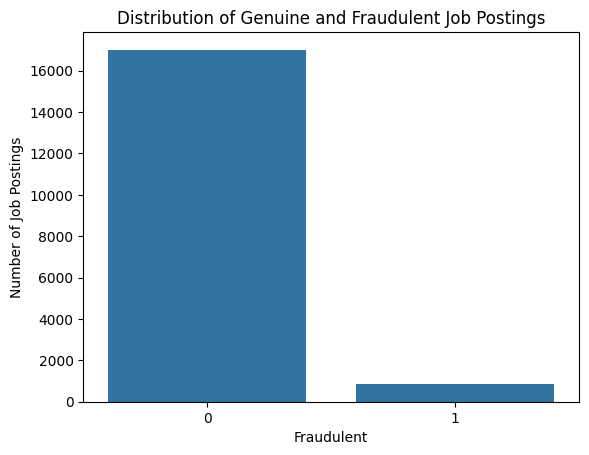

In [17]:
sns.countplot(data=df, x="fraudulent")
plt.title("Distribution of Genuine and Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")
plt.show()

In [18]:
target_labels = df["fraudulent"].map({
    0: "Genuine",
    1: "Fraudulent"
})

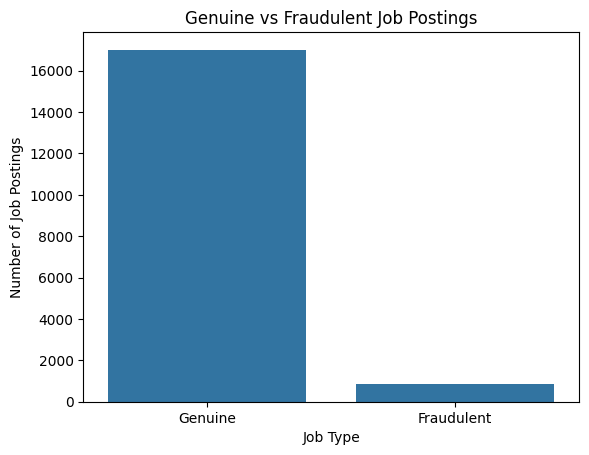

In [19]:
sns.countplot(x=target_labels)

plt.title("Genuine vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.show()

In [20]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for col in binary_columns:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df[col],
            df["fraudulent"],
            normalize="index"
        ).round(3)
    )


--- telecommuting ---
fraudulent         0      1
telecommuting              
0              0.953  0.047
1              0.917  0.083

--- has_company_logo ---
fraudulent            0      1
has_company_logo              
0                 0.841  0.159
1                 0.980  0.020

--- has_questions ---
fraudulent         0      1
has_questions              
0              0.932  0.068
1              0.972  0.028


In [21]:
columns_to_check = [
    "salary_range",
    "company_profile",
    "requirements",
    "benefits",
    "location",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in columns_to_check:
    missing_rate = (
        df.groupby(df[col].isna())["fraudulent"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(f"\n--- {col} ---")
    print(missing_rate)


--- salary_range ---
salary_range
False    7.78
True     4.28
Name: fraudulent, dtype: float64

--- company_profile ---
company_profile
False     1.91
True     17.74
Name: fraudulent, dtype: float64

--- requirements ---
requirements
False    4.69
True     5.71
Name: fraudulent, dtype: float64

--- benefits ---
benefits
False    4.71
True     5.05
Name: fraudulent, dtype: float64

--- location ---
location
False    4.83
True     5.49
Name: fraudulent, dtype: float64

--- employment_type ---
employment_type
False    4.34
True     6.94
Name: fraudulent, dtype: float64

--- required_experience ---
required_experience
False    3.98
True     6.17
Name: fraudulent, dtype: float64

--- required_education ---
required_education
False    4.25
True     5.56
Name: fraudulent, dtype: float64

--- industry ---
industry
False    4.55
True     5.61
Name: fraudulent, dtype: float64

--- function ---
function
False    4.63
True     5.22
Name: fraudulent, dtype: float64


## Text Characteristics

In [22]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [23]:
for col in text_columns:
    df[f"{col}_char_length"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.len()
    )

    df[f"{col}_word_count"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

In [24]:
length_columns = [
    "title_char_length",
    "company_profile_char_length",
    "description_char_length",
    "requirements_char_length",
    "benefits_char_length"
]

df[length_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
title_char_length,17880.0,28.530313,13.871256,3.0,19.0,25.0,35.0,142.0
company_profile_char_length,17880.0,620.901454,567.454100,0.0,138.0,570.0,879.0,6178.0
description_char_length,17880.0,1218.004418,894.828620,0.0,607.0,1017.0,1586.0,14907.0
requirements_char_length,17880.0,590.132215,613.191270,0.0,146.0,467.0,820.0,10864.0
benefits_char_length,17880.0,208.895694,337.077357,0.0,0.0,45.0,294.0,4429.0


In [25]:
text_analysis = df.groupby("fraudulent")[
    length_columns
].mean().round(2)

text_analysis

,title_char_length,company_profile_char_length,description_char_length,requirements_char_length,benefits_char_length
fraudulent,,,,,
0,28.42,640.75,1221.22,597.47,208.73
1,30.67,230.89,1154.83,446.05,212.20


In [26]:
word_count_columns = [
    "title_word_count",
    "company_profile_word_count",
    "description_word_count",
    "requirements_word_count",
    "benefits_word_count"
]

df.groupby("fraudulent")[word_count_columns].mean().round(2)

,title_word_count,company_profile_word_count,description_word_count,requirements_word_count,benefits_word_count
fraudulent,,,,,
0,3.75,95.65,171.04,79.03,30.02
1,4.02,31.71,158.75,58.41,29.45


In [27]:
df["total_text_char_length"] = (
    df["title_char_length"]
    + df["company_profile_char_length"]
    + df["description_char_length"]
    + df["requirements_char_length"]
    + df["benefits_char_length"]
)

In [28]:
df["total_text_word_count"] = (
    df["title_word_count"]
    + df["company_profile_word_count"]
    + df["description_word_count"]
    + df["requirements_word_count"]
    + df["benefits_word_count"]
)

In [29]:
df.groupby("fraudulent")[
    ["total_text_char_length", "total_text_word_count"]
].mean().round(2)

,total_text_char_length,total_text_word_count
fraudulent,,
0,2696.59,379.49
1,2074.64,282.33


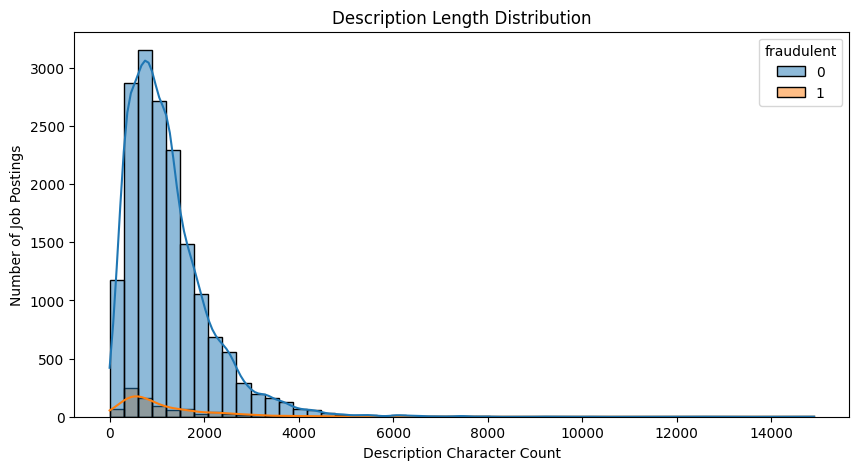

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="description_char_length",
    hue="fraudulent",
    bins=50,
    kde=True
)

plt.title("Description Length Distribution")
plt.xlabel("Description Character Count")
plt.ylabel("Number of Job Postings")
plt.show()

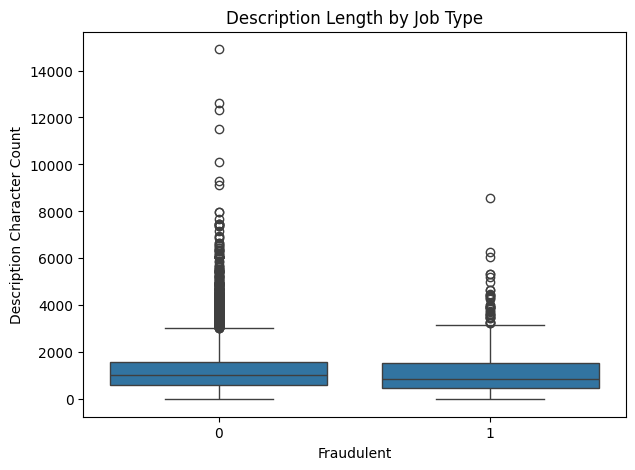

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_char_length"
)

plt.title("Description Length by Job Type")
plt.xlabel("Fraudulent")
plt.ylabel("Description Character Count")
plt.show()

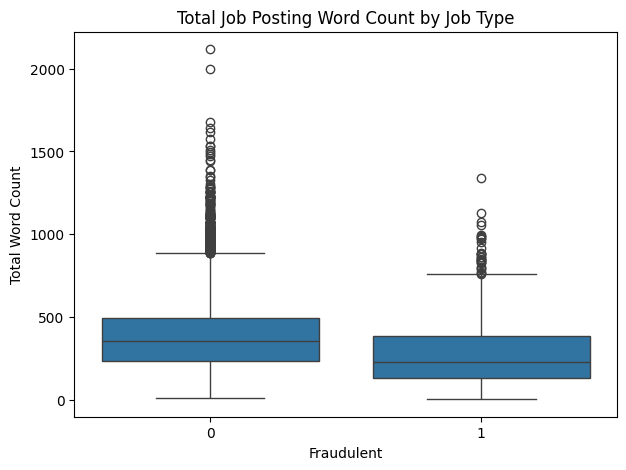

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="total_text_word_count"
)

plt.title("Total Job Posting Word Count by Job Type")
plt.xlabel("Fraudulent")
plt.ylabel("Total Word Count")
plt.show()

In [33]:
df[length_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
title_char_length,17880.0,28.530313,13.871256,3.0,19.0,25.0,35.0,142.0
company_profile_char_length,17880.0,620.901454,567.454100,0.0,138.0,570.0,879.0,6178.0
description_char_length,17880.0,1218.004418,894.828620,0.0,607.0,1017.0,1586.0,14907.0
requirements_char_length,17880.0,590.132215,613.191270,0.0,146.0,467.0,820.0,10864.0
benefits_char_length,17880.0,208.895694,337.077357,0.0,0.0,45.0,294.0,4429.0


In [34]:
df.groupby("fraudulent")[length_columns].mean().round(2)

,title_char_length,company_profile_char_length,description_char_length,requirements_char_length,benefits_char_length
fraudulent,,,,,
0,28.42,640.75,1221.22,597.47,208.73
1,30.67,230.89,1154.83,446.05,212.20


In [35]:
df.groupby("fraudulent")[word_count_columns].mean().round(2)

,title_word_count,company_profile_word_count,description_word_count,requirements_word_count,benefits_word_count
fraudulent,,,,,
0,3.75,95.65,171.04,79.03,30.02
1,4.02,31.71,158.75,58.41,29.45


In [36]:
df.groupby("fraudulent")[
    ["total_text_char_length", "total_text_word_count"]
].mean().round(2)

,total_text_char_length,total_text_word_count
fraudulent,,
0,2696.59,379.49
1,2074.64,282.33


## Categorical Feature Analysis

In [37]:
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")
    print(df[col].value_counts(dropna=False).head(10))


employment_type
employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

required_experience
required_experience
NaN                 7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

required_education
required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Name: count, dtype: int64

industry
industry
NaN                                    4903
Information 

In [38]:
for col in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"{col} - Fraud Rate")
    print(f"{'=' * 60}")

    fraud_rate = (
        df.groupby(col, dropna=False)["fraudulent"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(fraud_rate.head(10).round(2))


employment_type - Fraud Rate
employment_type
Part-time    9.28
NaN          6.94
Other        6.61
Full-time    4.22
Contract     2.89
Temporary    0.83
Name: fraudulent, dtype: float64

required_experience - Fraud Rate
required_experience
Executive           7.09
Entry level         6.64
NaN                 6.17
Not Applicable      5.38
Director            4.37
Mid-Senior level    2.97
Internship          2.62
Associate           1.83
Name: fraudulent, dtype: float64

required_education - Fraud Rate
required_education
Some High School Coursework          74.07
Certification                        11.18
High School or equivalent             8.17
Master's Degree                       7.45
NaN                                   5.56
Professional                          5.41
Unspecified                           4.37
Doctorate                             3.85
Some College Coursework Completed     2.94
Associate Degree                      2.19
Name: fraudulent, dtype: float64

industry -

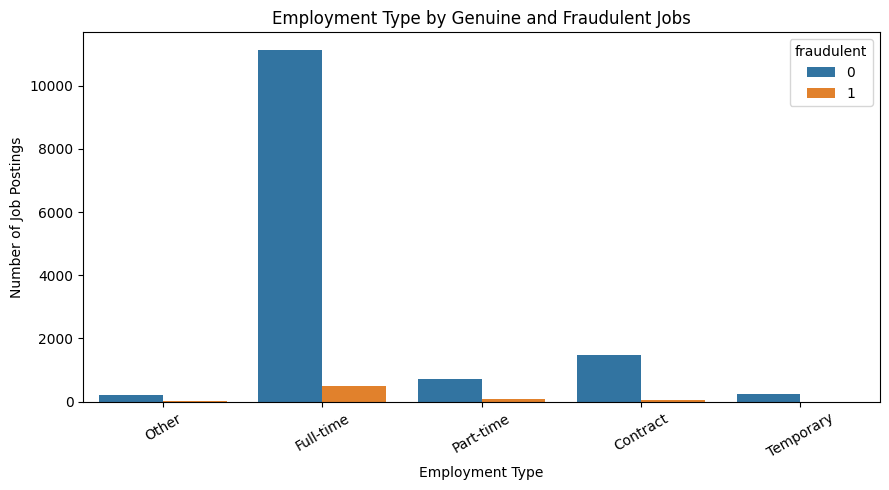

In [39]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="employment_type",
    hue="fraudulent"
)

plt.title("Employment Type by Genuine and Fraudulent Jobs")
plt.xlabel("Employment Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

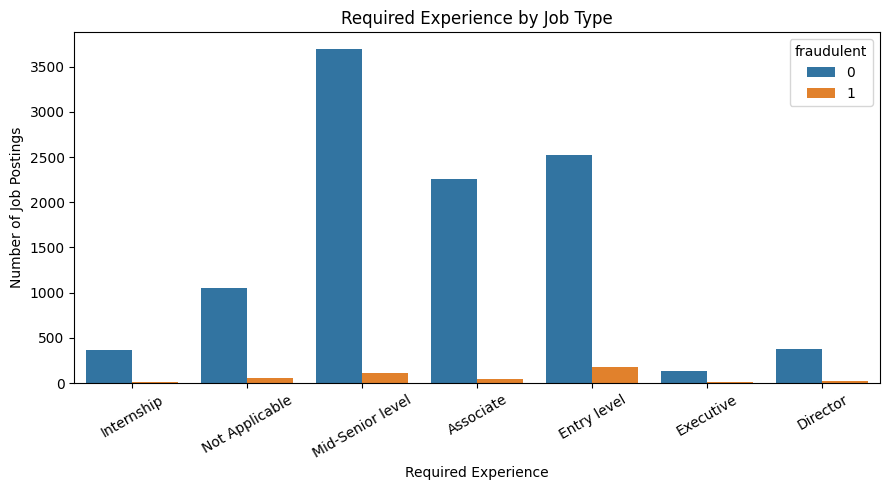

In [40]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="required_experience",
    hue="fraudulent"
)

plt.title("Required Experience by Job Type")
plt.xlabel("Required Experience")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [41]:
experience_fraud_rate = (
    df.groupby("required_experience", dropna=False)["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

experience_fraud_rate.round(2)

required_experience
Executive           7.09
Entry level         6.64
NaN                 6.17
Not Applicable      5.38
Director            4.37
Mid-Senior level    2.97
Internship          2.62
Associate           1.83
Name: fraudulent, dtype: float64

In [42]:
education_fraud_rate = (
    df.groupby("required_education", dropna=False)["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

education_fraud_rate.round(2)

required_education
Some High School Coursework          74.07
Certification                        11.18
High School or equivalent             8.17
Master's Degree                       7.45
NaN                                   5.56
Professional                          5.41
Unspecified                           4.37
Doctorate                             3.85
Some College Coursework Completed     2.94
Associate Degree                      2.19
Bachelor's Degree                     1.94
Vocational                            0.00
Vocational - Degree                   0.00
Vocational - HS Diploma               0.00
Name: fraudulent, dtype: float64

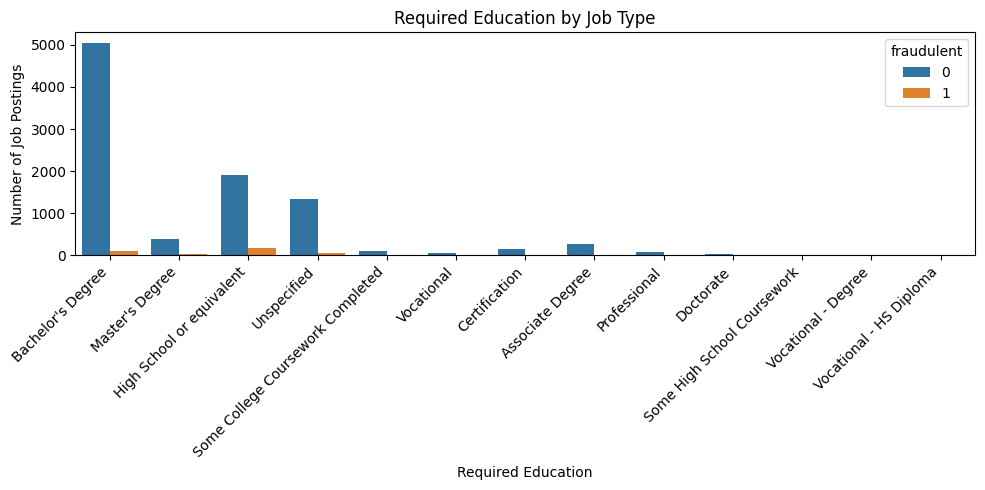

In [43]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="required_education",
    hue="fraudulent"
)

plt.title("Required Education by Job Type")
plt.xlabel("Required Education")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [44]:
top_industries = df["industry"].value_counts().head(10)

top_industries

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Name: count, dtype: int64

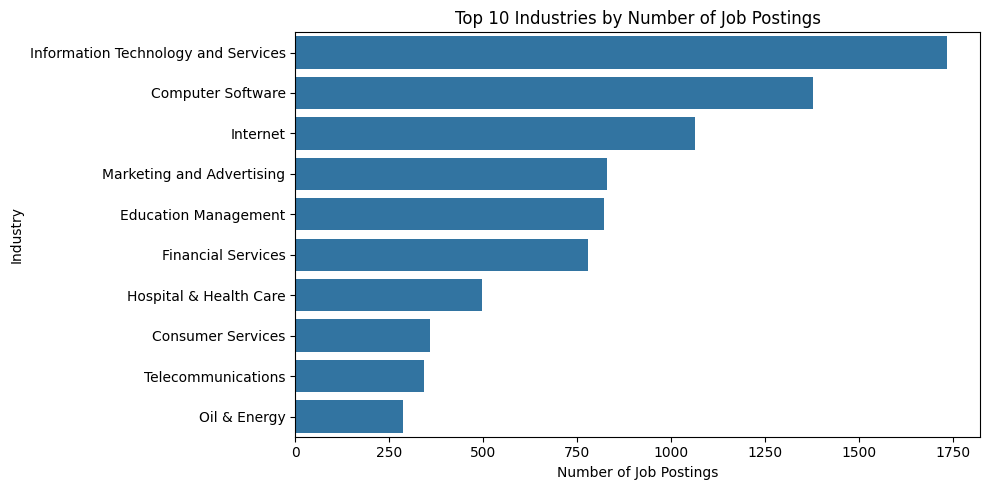

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index
)

plt.title("Top 10 Industries by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

In [46]:
top_industry_names = top_industries.index

industry_fraud_rate = (
    df[df["industry"].isin(top_industry_names)]
    .groupby("industry")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

industry_fraud_rate.round(2)

industry
Oil & Energy                           37.98
Hospital & Health Care                 10.26
Telecommunications                      7.60
Consumer Services                       6.70
Marketing and Advertising               5.43
Financial Services                      4.49
Information Technology and Services     1.85
Computer Software                       0.36
Education Management                    0.00
Internet                                0.00
Name: fraudulent, dtype: float64

In [47]:
top_functions = df["function"].value_counts().head(10)

top_functions

function
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Name: count, dtype: int64

In [48]:
function_fraud_rate = (
    df[df["function"].isin(top_functions.index)]
    .groupby("function")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

function_fraud_rate.round(2)

function
Administrative            18.89
Other                      9.85
Engineering                8.38
Customer Service           5.45
Sales                      2.79
Information Technology     1.83
Marketing                  1.20
Design                     0.88
Education                  0.31
Health Care Provider       0.30
Name: fraudulent, dtype: float64

In [49]:
df["location"].value_counts(dropna=False).head(15)

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
NaN                      346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
Name: count, dtype: int64

In [50]:
top_locations = df["location"].value_counts().head(10)

top_locations

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
Name: count, dtype: int64

In [51]:
df["department"].value_counts(dropna=False).head(15)

department
NaN                       11547
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Design                       76
Technology                   76
Customer Service             73
Finance                      69
HR                           56
tech                         55
Name: count, dtype: int64

In [52]:
df["employment_type"].value_counts(dropna=False)

employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [53]:
(
    df.groupby("employment_type", dropna=False)["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

employment_type
Part-time    9.28
NaN          6.94
Other        6.61
Full-time    4.22
Contract     2.89
Temporary    0.83
Name: fraudulent, dtype: float64

In [54]:
experience_fraud_rate.round(2)

required_experience
Executive           7.09
Entry level         6.64
NaN                 6.17
Not Applicable      5.38
Director            4.37
Mid-Senior level    2.97
Internship          2.62
Associate           1.83
Name: fraudulent, dtype: float64

In [55]:
education_fraud_rate.round(2)

required_education
Some High School Coursework          74.07
Certification                        11.18
High School or equivalent             8.17
Master's Degree                       7.45
NaN                                   5.56
Professional                          5.41
Unspecified                           4.37
Doctorate                             3.85
Some College Coursework Completed     2.94
Associate Degree                      2.19
Bachelor's Degree                     1.94
Vocational                            0.00
Vocational - Degree                   0.00
Vocational - HS Diploma               0.00
Name: fraudulent, dtype: float64

In [56]:
top_industries
industry_fraud_rate.round(2)

industry
Oil & Energy                           37.98
Hospital & Health Care                 10.26
Telecommunications                      7.60
Consumer Services                       6.70
Marketing and Advertising               5.43
Financial Services                      4.49
Information Technology and Services     1.85
Computer Software                       0.36
Education Management                    0.00
Internet                                0.00
Name: fraudulent, dtype: float64

In [57]:
top_functions
function_fraud_rate.round(2)

function
Administrative            18.89
Other                      9.85
Engineering                8.38
Customer Service           5.45
Sales                      2.79
Information Technology     1.83
Marketing                  1.20
Design                     0.88
Education                  0.31
Health Care Provider       0.30
Name: fraudulent, dtype: float64

In [58]:
df["location"].value_counts(dropna=False).head(15)

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
NaN                      346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
Name: count, dtype: int64

In [59]:
df["department"].value_counts(dropna=False).head(15)

department
NaN                       11547
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Design                       76
Technology                   76
Customer Service             73
Finance                      69
HR                           56
tech                         55
Name: count, dtype: int64

In [60]:
df["employment_type"].value_counts(dropna=False)

employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [61]:
(
    df.groupby("employment_type", dropna=False)["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

employment_type
Part-time    9.28
NaN          6.94
Other        6.61
Full-time    4.22
Contract     2.89
Temporary    0.83
Name: fraudulent, dtype: float64

In [62]:
experience_fraud_rate.round(2)

required_experience
Executive           7.09
Entry level         6.64
NaN                 6.17
Not Applicable      5.38
Director            4.37
Mid-Senior level    2.97
Internship          2.62
Associate           1.83
Name: fraudulent, dtype: float64

In [63]:
education_fraud_rate.round(2)

required_education
Some High School Coursework          74.07
Certification                        11.18
High School or equivalent             8.17
Master's Degree                       7.45
NaN                                   5.56
Professional                          5.41
Unspecified                           4.37
Doctorate                             3.85
Some College Coursework Completed     2.94
Associate Degree                      2.19
Bachelor's Degree                     1.94
Vocational                            0.00
Vocational - Degree                   0.00
Vocational - HS Diploma               0.00
Name: fraudulent, dtype: float64

In [64]:
top_industries
industry_fraud_rate.round(2)

industry
Oil & Energy                           37.98
Hospital & Health Care                 10.26
Telecommunications                      7.60
Consumer Services                       6.70
Marketing and Advertising               5.43
Financial Services                      4.49
Information Technology and Services     1.85
Computer Software                       0.36
Education Management                    0.00
Internet                                0.00
Name: fraudulent, dtype: float64

In [65]:
top_functions
function_fraud_rate.round(2)

function
Administrative            18.89
Other                      9.85
Engineering                8.38
Customer Service           5.45
Sales                      2.79
Information Technology     1.83
Marketing                  1.20
Design                     0.88
Education                  0.31
Health Care Provider       0.30
Name: fraudulent, dtype: float64

In [66]:
education_analysis = (
    df.groupby("required_education", dropna=False)["fraudulent"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

education_analysis

,count,sum,mean
required_education,,,
Some High School Coursework,27,20,0.740741
Certification,170,19,0.111765
High School or equivalent,2080,170,0.081731
Master's Degree,416,31,0.074519
NaN,8105,451,0.055645
Professional,74,4,0.054054
Unspecified,1397,61,0.043665
Doctorate,26,1,0.038462
Some College Coursework Completed,102,3,0.029412


In [67]:
education_analysis["fraud_rate"] = (
    education_analysis["mean"] * 100
).round(2)

education_analysis

,count,sum,mean,fraud_rate
required_education,,,,
Some High School Coursework,27,20,0.740741,74.07
Certification,170,19,0.111765,11.18
High School or equivalent,2080,170,0.081731,8.17
Master's Degree,416,31,0.074519,7.45
NaN,8105,451,0.055645,5.56
Professional,74,4,0.054054,5.41
Unspecified,1397,61,0.043665,4.37
Doctorate,26,1,0.038462,3.85
Some College Coursework Completed,102,3,0.029412,2.94


In [68]:
industry_analysis = (
    df.groupby("industry", dropna=False)["fraudulent"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

industry_analysis["fraud_rate"] = (
    industry_analysis["mean"] * 100
).round(2)

industry_analysis.head(15)

,count,sum,mean,fraud_rate
industry,,,,
Ranching,1,1,1.000000,100.00
Military,2,1,0.500000,50.00
Animation,5,2,0.400000,40.00
Oil & Energy,287,109,0.379791,37.98
Accounting,159,57,0.358491,35.85
"Leisure, Travel & Tourism",76,21,0.276316,27.63
Computer Networking,44,12,0.272727,27.27
Executive Office,8,2,0.250000,25.00
Defense & Space,9,2,0.222222,22.22


In [69]:
function_analysis = (
    df.groupby("function", dropna=False)["fraudulent"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

function_analysis["fraud_rate"] = (
    function_analysis["mean"] * 100
).round(2)

function_analysis.head(15)

,count,sum,mean,fraud_rate
function,,,,
Administrative,630,119,0.188889,18.89
Financial Analyst,33,5,0.151515,15.15
Accounting/Auditing,212,29,0.136792,13.68
Distribution,24,3,0.125000,12.50
Other,325,32,0.098462,9.85
Finance,172,15,0.087209,8.72
Engineering,1348,113,0.083828,8.38
Business Development,228,13,0.057018,5.70
Advertising,90,5,0.055556,5.56
